# Assignment 2: Learn!
## Created by: Jaydin Rethmel

### Dataset

The dataset that will be used within this assignment is a dataset containing attributes and information for the 2025 spotify wrapped playlist.

URL = "https://www.kaggle.com/datasets/alitaqishah/spotify-wrapped-2025-top-songs-and-artists"

This dataset contains 3 file, however we will be using one specifically. This file is called `spotify_wrapped_2025_top50_songs.csv` which contains the attributes song_title, artist, streams_2025_billions, total_streams_billions_primary_genre, bpm, duration_seconds, release_year, artist_country, explicit, danceability, energy, valence, acousticness, and peak_global_chart_position

### What Will Be Classified

Using an ensemble, we will be identify the corralation between `total_streams_billions` and `acousticness` or in the form of the question we are looking to answer, is their a postive or negitive impact in streams comparing acoustic dominate music and electric dominate music.

In [ ]:
# Used Copilot to generate the code for this assignment
# but I edited it to fit the dataset and requirements of the assignment.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('spotify_wrapped_2025_top50_songs.csv')

# Display the first few rows
print(df.head())

# Basic info
print(df.info())

# For ensemble setup, let's assume we want to predict streams_2025_billions based on features
# Features: bpm, duration_seconds, release_year, danceability, energy, valence, acousticness
features = ['bpm', 'duration_seconds', 'release_year', 'danceability', 'energy', 'valence', 'acousticness']
target = 'streams_2025_billions'

# Drop rows with missing values for simplicity
df = df.dropna(subset=features + [target])

# Split the data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a Random Forest Regressor as an example ensemble model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# To analyze correlation between acousticness and streams
correlation = df['acousticness'].corr(df['streams_2025_billions'])
print(f'Correlation between acousticness and streams_2025_billions: {correlation}')

   wrapped_2025_rank            song_title                  artist  \
0                  1      Die With A Smile  Lady Gaga & Bruno Mars   
1                  2                  APT.       ROSE & Bruno Mars   
2                  3              Espresso       Sabrina Carpenter   
3                  4  Please Please Please       Sabrina Carpenter   
4                  5                 Taste       Sabrina Carpenter   

   streams_2025_billions primary_genre  bpm  duration_seconds  release_year  \
0                   1.70           Pop  120               251          2024   
1                   1.62     K-Pop/Pop  145               173          2024   
2                   1.55           Pop  104               175          2024   
3                   1.48           Pop  107               186          2024   
4                   1.41           Pop  117               177          2024   

  artist_country  explicit  danceability  energy  valence  acousticness  \
0            USA     False   

### Breakdown of Results

With the correlation value we found `-0.12651 (rounded)`, we have found that music that is more accostic (acousticness value of 0 reprsenting completely accostic, while 1 representing completely electric) has a 12.7 percent increase in listens compared to electric music.

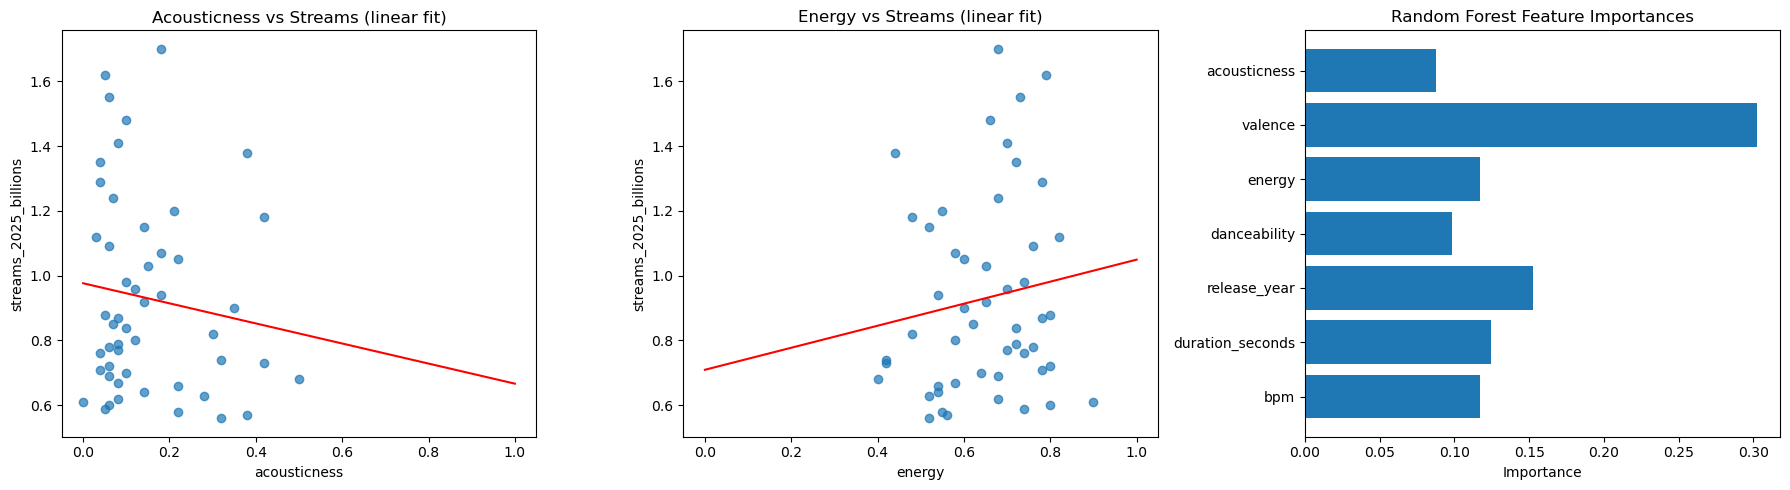

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Scatter + linear regression line for acousticness vs streams
X_acoustic = df[['acousticness']].values
y_streams = df['streams_2025_billions'].values
lr = LinearRegression().fit(X_acoustic, y_streams)
y_pred_line = lr.predict(np.linspace(0, 1, 200).reshape(-1, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_acoustic, y_streams, alpha=0.7)
axs[0].plot(np.linspace(0, 1, 200), y_pred_line, color='red')
axs[0].set_title('Acousticness vs Streams (linear fit)')
axs[0].set_xlabel('acousticness')
axs[0].set_ylabel('streams_2025_billions')

# 2) Scatter + linear regression line for energy vs streams
X_energy = df[['energy']].values
lr_energy = LinearRegression().fit(X_energy, y_streams)
y_pred_energy = lr_energy.predict(np.linspace(0, 1, 200).reshape(-1, 1))
axs[1].scatter(X_energy, y_streams, alpha=0.7)
axs[1].plot(np.linspace(0, 1, 200), y_pred_energy, color='red')
axs[1].set_title('Energy vs Streams (linear fit)')
axs[1].set_xlabel('energy')
axs[1].set_ylabel('streams_2025_billions')

# 3) Feature importance from the ensemble model (correlation proxy)
importances = model.feature_importances_
feature_names = features
axs[2].barh(feature_names, importances, color='tab:blue')
axs[2].set_title('Random Forest Feature Importances')
axs[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Conclusion

After looking at these graphs and the results from the beginning, there are several major factors that reveal interesting information within the 2025 Spotify wrapped top 50 songs. The first of these major points is that Acoustic music is significantly listened to more often than electric. Its important to notice on the chart that out of the top 50 songs, only one song is listed at a 0.5 acousticness score, meaning that the data is mostly shewed to this factor.

The second factor that shows interesting data is the second chart created, which shows how the Spotify energy score is reflected within those top 50 songs. This chart reveals that songs that have a higher energy score tend to average higher listeners than low energy music, however similarly to the Acousticness vs Streams chart, only one song is at a 0.4 or lower energy score. This shows that the correlation regression line is most likely slightly off in terms of accuracy.

The last piece centered around this dataset is how the Random Forest feature importances is scaled. The model identified valence (an indication of postive tones with a song, where 0 is negative centered music while 1 is positive centered music) as the most important feature with relation to listens. This shows that both moody and positive music have a large effect on listens while acosticness is the lowest importance with relation to views.